# 01 EDA: IEEE-CIS Fraud Detection

Этот ноутбук относится к `Неделе 1` и нужен для первого исследовательского анализа данных.

Цель:
- понять структуру `train_transaction`;
- проверить качество данных;
- сравнить fraud и non-fraud сегменты;
- найти первые suspicious patterns;
- подготовить гипотезы для anti-fraud правил и будущих признаков.

## План работы

1. Настроить пути к данным.
2. Загрузить `train_transaction` и при необходимости `train_identity`.
3. Посмотреть размер таблиц, типы колонок и target.
4. Проверить пропуски и базовое качество данных.
5. Изучить `TransactionAmt`, `ProductCD`, `card*`, `addr*`, `emaildomain`.
6. Посмотреть временные паттерны по `TransactionDT`.
7. Зафиксировать 5-10 гипотез для следующего шага.

In [13]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")


In [14]:
# TODO: update these paths after you download the dataset.
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
TRANSACTION_PATH = DATA_DIR / "train_transaction.csv"
IDENTITY_PATH = DATA_DIR / "train_identity.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRANSACTION_PATH:", TRANSACTION_PATH)
print("IDENTITY_PATH:", IDENTITY_PATH)

PROJECT_ROOT: /Users/drhtka/Downloads/Projects/Llm_ml_RAG/anti_fraud_analytics_platform
TRANSACTION_PATH: /Users/drhtka/Downloads/Projects/Llm_ml_RAG/anti_fraud_analytics_platform/data/train_transaction.csv
IDENTITY_PATH: /Users/drhtka/Downloads/Projects/Llm_ml_RAG/anti_fraud_analytics_platform/data/train_identity.csv


In [17]:
def load_csv_if_exists(path: Path):
    if path.exists():
        print(f"Loaded: {path.name}")
        return pd.read_csv(path)
    print(f"File not found: {path}")
    return None


transactions = load_csv_if_exists(TRANSACTION_PATH)
identity = load_csv_if_exists(IDENTITY_PATH)


Loaded: train_transaction.csv
Loaded: train_identity.csv


## 1. Быстрый обзор данных

На этом этапе важно ответить на вопросы:
- сколько строк и колонок;
- есть ли `isFraud`;
- какие типы данных преобладают;
- какие поля выглядят понятными уже сейчас.

In [18]:
if transactions is not None:
    print("transactions shape:", transactions.shape)
    display(transactions.head())
else:
    print("Load train_transaction.csv first.")

transactions shape: (590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,...,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,F,F,F,F,F,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,T,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [19]:
if transactions is not None:
    overview = pd.DataFrame({
        "dtype": transactions.dtypes.astype(str),
        "missing_cnt": transactions.isna().sum(),
        "missing_pct": (transactions.isna().mean() * 100).round(2),
        "nunique": transactions.nunique(dropna=False)
    }).sort_values(["missing_pct", "nunique"], ascending=[False, False])
    display(overview.head(30))
else:
    print("No data to inspect.")

,dtype,missing_cnt,missing_pct,nunique
dist2,float64,552913,93.63,1752
D7,float64,551623,93.41,598
D13,float64,528588,89.51,578
D14,float64,528353,89.47,803
D12,float64,525823,89.04,636
D6,float64,517353,87.61,830
D8,float64,515614,87.31,12354
D9,float64,515614,87.31,25
V160,float64,508589,86.12,9622
V159,float64,508589,86.12,6664


## 2. Target и class imbalance

Для anti-fraud это обязательный шаг. Нужно сразу понять, насколько редок fraud-класс.

,isFraud,cnt,pct
0,0,569877,96.501
1,1,20663,3.499


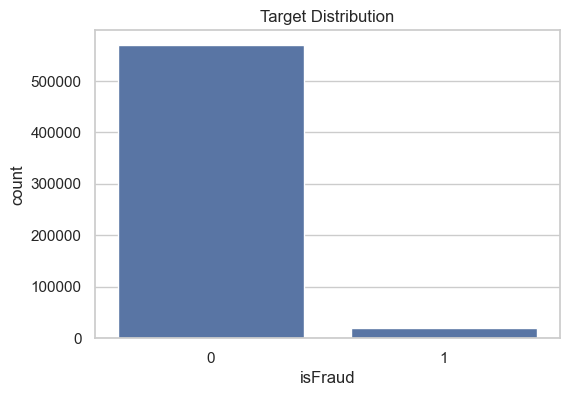

In [20]:
if transactions is not None and "isFraud" in transactions.columns:
    target_stats = transactions["isFraud"].value_counts(dropna=False).rename_axis("isFraud").reset_index(name="cnt")
    target_stats["pct"] = (target_stats["cnt"] / len(transactions) * 100).round(4)
    display(target_stats)

    plt.figure(figsize=(6, 4))
    sns.countplot(data=transactions, x="isFraud")
    plt.title("Target Distribution")
    plt.show()
else:
    print("Column isFraud not found.")

## 3. Пропуски

Здесь ищем поля, которые:
- почти пустые;
- могут мешать интерпретации;
- потребуют отдельной стратегии перед моделью.

In [21]:
if transactions is not None:
    missing = (
        transactions.isna().mean()
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"index": "field", 0: "missing_pct"})
    )
    missing["missing_pct"] = (missing["missing_pct"] * 100).round(2)
    display(missing.head(20))
else:
    print("No data to inspect missing values.")

,field,missing_pct
0,dist2,93.63
1,D7,93.41
2,D13,89.51
3,D14,89.47
4,D12,89.04
5,D6,87.61
6,D9,87.31
7,D8,87.31
8,V153,86.12
9,V149,86.12


## 4. Сумма транзакции

На первом этапе `TransactionAmt` почти всегда один из самых полезных признаков.

Проверь:
- выбросы;
- различия fraud vs non-fraud;
- есть ли длинный хвост распределения.

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
50%          68.769000
75%         125.000000
90%         275.293000
95%         445.000000
99%        1104.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

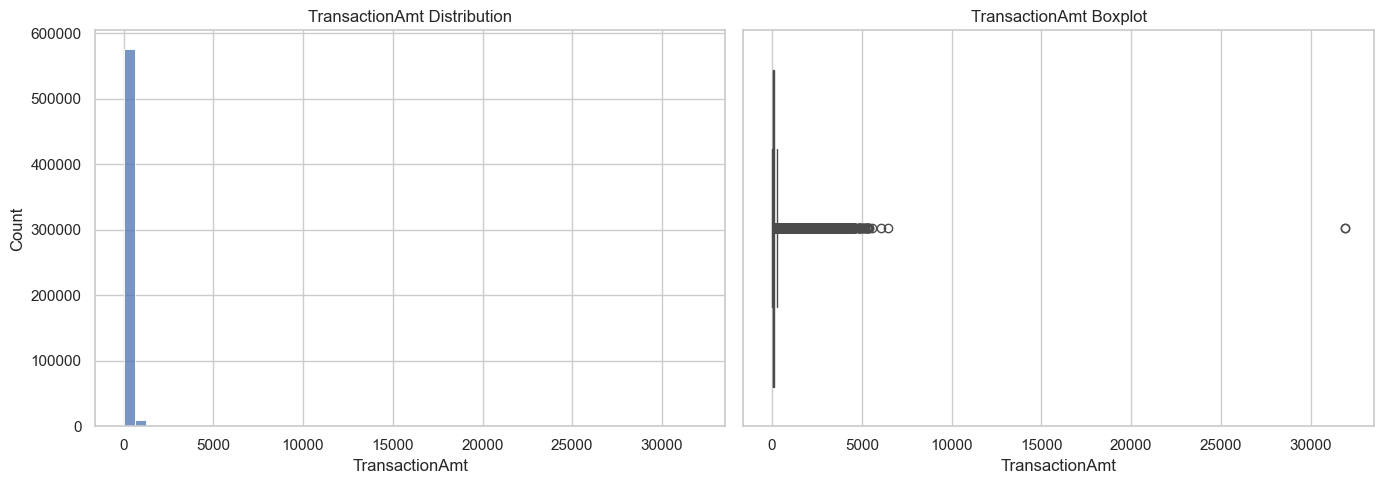

In [23]:
if transactions is not None and "TransactionAmt" in transactions.columns:
    display(transactions["TransactionAmt"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(transactions["TransactionAmt"], bins=50, ax=axes[0])
    axes[0].set_title("TransactionAmt Distribution")

    sns.boxplot(x=transactions["TransactionAmt"], ax=axes[1])
    axes[1].set_title("TransactionAmt Boxplot")
    plt.tight_layout()
    plt.show()
else:
    print("Column TransactionAmt not found.")

In [24]:
if transactions is not None and {"TransactionAmt", "isFraud"}.issubset(transactions.columns):
    display(
        transactions.groupby("isFraud")["TransactionAmt"].describe().round(2)
    )
else:
    print("Required columns not found.")

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.51,239.40,0.25,43.97,68.5,120.0,31937.39
1,20663.0,149.24,232.21,0.29,35.04,75.0,161.0,5191.00


## 5. Категориальные поля

Рекомендуемый минимум для первого прохода:
- `ProductCD`
- `card4`
- `card6`
- `P_emaildomain`
- `R_emaildomain`

Идея: посмотреть частоты категорий и fraud rate по ним.

In [25]:
def categorical_fraud_summary(df, column, top_n=15):
    if df is None or column not in df.columns or "isFraud" not in df.columns:
        print(f"Skip column: {column}")
        return None

    summary = (
        df.groupby(column, dropna=False)
        .agg(tx_count=(column, "size"), fraud_rate=("isFraud", "mean"))
        .sort_values("tx_count", ascending=False)
        .head(top_n)
        .reset_index()
    )
    summary["fraud_rate"] = (summary["fraud_rate"] * 100).round(2)
    return summary


categorical_columns = ["ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain"]
for col in categorical_columns:
    print(f"\n=== {col} ===")
    summary = categorical_fraud_summary(transactions, col)
    if summary is not None:
        display(summary)


=== ProductCD ===


,ProductCD,tx_count,fraud_rate
0,W,439670,2.04
1,C,68519,11.69
2,R,37699,3.78
3,H,33024,4.77
4,S,11628,5.90



=== card4 ===


,card4,tx_count,fraud_rate
0,visa,384767,3.48
1,mastercard,189217,3.43
2,american express,8328,2.87
3,discover,6651,7.73
4,NaN,1577,2.60



=== card6 ===


,card6,tx_count,fraud_rate
0,debit,439938,2.43
1,credit,148986,6.68
2,NaN,1571,2.48
3,debit or credit,30,0.00
4,charge card,15,0.00



=== P_emaildomain ===


,P_emaildomain,tx_count,fraud_rate
0,gmail.com,228355,4.35
1,yahoo.com,100934,2.28
2,NaN,94456,2.95
3,hotmail.com,45250,5.30
4,anonymous.com,36998,2.32
5,aol.com,28289,2.18
6,comcast.net,7888,3.12
7,icloud.com,6267,3.14
8,outlook.com,5096,9.46
9,msn.com,4092,2.20



=== R_emaildomain ===


,R_emaildomain,tx_count,fraud_rate
0,NaN,453249,2.08
1,gmail.com,57147,11.92
2,hotmail.com,27509,7.78
3,anonymous.com,20529,2.91
4,yahoo.com,11842,5.15
5,aol.com,3701,3.49
6,outlook.com,2507,16.51
7,comcast.net,1812,1.16
8,yahoo.com.mx,1508,1.06
9,icloud.com,1398,12.88


## 6. Временные паттерны

`TransactionDT` в этом датасете - не календарная дата, а относительное время.

На первом проходе достаточно:
- посмотреть распределение;
- разбить на крупные временные бакеты;
- сравнить fraud rate по этим бакетам.

In [26]:
if transactions is not None and {"TransactionDT", "isFraud"}.issubset(transactions.columns):
    display(transactions["TransactionDT"].describe())

    tx_dt = transactions[["TransactionDT", "isFraud"]].copy()
    tx_dt["dt_bin"] = pd.qcut(tx_dt["TransactionDT"], q=10, duplicates="drop")
    time_summary = tx_dt.groupby("dt_bin").agg(tx_count=("isFraud", "size"), fraud_rate=("isFraud", "mean")).reset_index()
    time_summary["fraud_rate"] = (time_summary["fraud_rate"] * 100).round(2)
    display(time_summary)
else:
    print("Required columns not found.")

count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

,dt_bin,tx_count,fraud_rate
0,"(86399.999, 1361004.4]",59054,2.76
1,"(1361004.4, 2310159.6]",59054,2.02
2,"(2310159.6, 3864163.9]",59054,3.73
3,"(3864163.9, 5592303.6]",59054,4.29
4,"(5592303.6, 7306527.5]",59054,3.96
5,"(7306527.5, 8745782.4]",59054,3.55
6,"(8745782.4, 10437998.1]",59054,4.32
7,"(10437998.1, 12192853.6]",59054,3.49
8,"(12192853.6, 13990907.7]",59054,3.13
9,"(13990907.7, 15811131.0]",59054,3.75


## 7. Поля из data dictionary

Сфокусируйся на полях из `data_dictionary_ieee_cis_v1.md`:
- `TransactionAmt`
- `ProductCD`
- `card1`, `card4`, `card6`
- `addr1`, `addr2`
- `dist1`
- `P_emaildomain`, `R_emaildomain`
- `TransactionDT`

Для каждого ответь:
- есть ли пропуски;
- понятен ли смысл;
- виден ли fraud signal;
- годится ли поле для rule-based гипотез.

In [27]:
candidate_columns = [
    "TransactionAmt", "ProductCD", "card1", "card4", "card6",
    "addr1", "addr2", "dist1", "P_emaildomain", "R_emaildomain", "TransactionDT", "isFraud"
]

if transactions is not None:
    existing_columns = [col for col in candidate_columns if col in transactions.columns]
    display(transactions[existing_columns].head())
else:
    print("No data loaded.")

,TransactionAmt,ProductCD,card1,card4,card6,addr1,addr2,dist1,P_emaildomain,R_emaildomain,TransactionDT,isFraud
0,68.5,W,13926,discover,credit,315.0,87.0,19.0,NaN,NaN,86400,0
1,29.0,W,2755,mastercard,credit,325.0,87.0,NaN,gmail.com,NaN,86401,0
2,59.0,W,4663,visa,debit,330.0,87.0,287.0,outlook.com,NaN,86469,0
3,50.0,W,18132,mastercard,debit,476.0,87.0,NaN,yahoo.com,NaN,86499,0
4,50.0,H,4497,mastercard,credit,420.0,87.0,NaN,gmail.com,NaN,86506,0


## 8. Гипотезы

Заполни после первого прохода.

Шаблон:
1. Гипотеза:
2. На каком поле основана:
3. Почему это может быть suspicious:
4. Как это проверить в `SQL`:
5. Можно ли превратить это в правило или признак:


In [2]:
hypotheses = [
    "1. Транзакции с ProductCD = C имеют повышенный fraud risk, потому что fraud rate в этом сегменте заметно выше остальных.",
    "2. Транзакции с card4 = discover чаще относятся к fraud, чем транзакции с visa и mastercard.",
    "3. Транзакции с card6 = credit имеют повышенный fraud risk по сравнению с debit.",
    "4. Отдельные email domains, особенно outlook.com, icloud.com и gmail.com, связаны с повышенным fraud rate и могут быть полезны для anti-fraud правил.",
    "5. Нетипично крупные транзакции относительно обычного уровня по customer-like proxy card1 могут быть сильным suspicious signal и кандидатом в manual review.",
]

for item in hypotheses:
    print(item)

1. Транзакции с ProductCD = C имеют повышенный fraud risk, потому что fraud rate в этом сегменте заметно выше остальных.
2. Транзакции с card4 = discover чаще относятся к fraud, чем транзакции с visa и mastercard.
3. Транзакции с card6 = credit имеют повышенный fraud risk по сравнению с debit.
4. Отдельные email domains, особенно outlook.com, icloud.com и gmail.com, связаны с повышенным fraud rate и могут быть полезны для anti-fraud правил.
5. Нетипично крупные транзакции относительно обычного уровня по customer-like proxy card1 могут быть сильным suspicious signal и кандидатом в manual review.


## 9. Итог недели

К концу этого ноутбука у тебя должно быть:
- понимание структуры `train_transaction`;
- базовый обзор пропусков и типов данных;
- первые графики по `TransactionAmt` и target;
- первые fraud-сегменты по категориальным полям;
- 5-10 гипотез для `SQL` и anti-fraud логики.

Следующий шаг после этого ноутбука:
- усилить `SQL`-агрегации;
- подготовить первые rule-based идеи;
- при необходимости подключить `train_identity`.